<a href="https://colab.research.google.com/github/tustus1022-ui/esaa/blob/main/ESAA_OB_WEEK3_transcription1.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

<파이썬 머신러닝 완벽 가이드> 8장 p.566~583 필사

## 10. 텍스트 분석 실습 - 캐글 Mercari Price Suggestion Challenge
: 일본의 대형 온라인 쇼핑몰인 Mercari사의 제품에 대해 가격을 예측하는 과제

- 제품에 대한 여러 속성 및 제품 설명 등의 텍스트 데이터로 구성됨

제공되는 데이터 세트의 속성
- train_id : 데이터 id
- name : 제품명
- item_condition_id : 판매자가 제공하는 제품 상태
- category_name : 브랜드 이름
- price : 제품 가격, 예측을 위한 타깃 속성
- shipping : 배송비 무료 여부. 1이면 무료(판매자가 지불), 0이면 유료(구매자 지불)
- item_description : 제품에 대한 설명

-> 이들 중 price가 예측해야 할 타깃 값
- 회귀로 피처 학습 -> price 예측
- 기존 회귀 예제와 다른 점 : item_description과 같은 텍스트 형태의 비정형 데이터와 다른 정형 속성을 같이 적용해 회귀를 수행

### **데이터 전처리**
- 필요한 라이브러리와 함꼐 mercari_tratin.tsv 데이터를 DataFrame으로 로딩하고 데이터를 간략하게 살펴보기

In [11]:
from sklearn.linear_model import Ridge, LogisticRegression
from sklearn.model_selection import train_test_split, cross_val_score
from sklearn.feature_extraction.text import CountVectorizer, TfidfVectorizer
import pandas as pd

mercari_df=pd.read_csv('mercari_train.tsv', sep='\t')
print(mercari_df.shape)
mercari_df.head(3)

(1482535, 8)


,train_id,name,item_condition_id,category_name,brand_name,price,shipping,item_description
0,0,MLB Cincinnati Reds T Shirt Size XL,3,Men/Tops/T-shirts,NaN,10.0,1,No description yet
1,1,Razer BlackWidow Chroma Keyboard,3,Electronics/Computers & Tablets/Components & P...,Razer,52.0,0,This keyboard is in great condition and works ...
2,2,AVA-VIV Blouse,1,Women/Tops & Blouses/Blouse,Target,10.0,1,Adorable top with a hint of lace and a key hol...


- 피처의 타입과 Null 여부 확인

In [12]:
print(mercari_df.info())

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 1482535 entries, 0 to 1482534
Data columns (total 8 columns):
 #   Column             Non-Null Count    Dtype  
---  ------             --------------    -----  
 0   train_id           1482535 non-null  int64  
 1   name               1482535 non-null  object 
 2   item_condition_id  1482535 non-null  int64  
 3   category_name      1476208 non-null  object 
 4   brand_name         849853 non-null   object 
 5   price              1482535 non-null  float64
 6   shipping           1482535 non-null  int64  
 7   item_description   1482529 non-null  object 
dtypes: float64(1), int64(3), object(4)
memory usage: 90.5+ MB
None


-> null 데이터는 이후에 적절한 문자열로 치환

- Target 값인 price 칼럼의 데이터 분포도 살피기

회귀에서 Target 값의 정규 분포도는 매우 중요함

왜곡돼 있을 경우 보통 로그를 씌워서 변환하면 대부분 정규 분포의 형태를 가지게 됨

/tmp/ipykernel_2017/1198184677.py:6: UserWarning: 

`distplot` is a deprecated function and will be removed in seaborn v0.14.0.

Please adapt your code to use either `displot` (a figure-level function with
similar flexibility) or `histplot` (an axes-level function for histograms).

For a guide to updating your code to use the new functions, please see
https://gist.github.com/mwaskom/de44147ed2974457ad6372750bbe5751

  sns.distplot(y_train_df, bins=100)


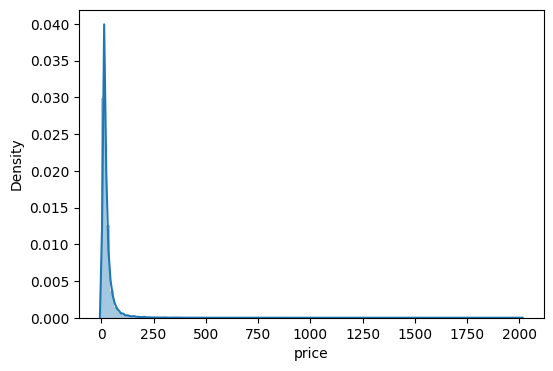

In [13]:
import matplotlib.pyplot as plt
import seaborn as sns

y_train_df = mercari_df['price']
plt.figure(figsize=(6, 4))
sns.distplot(y_train_df, bins=100)
plt.show()

-> 비교적 적은 가격을 가진 데이터 값에 왜곡돼 분포돼 있음

- Price 칼럼을 로그 값으로 변환한 뒤 분포도 살피기

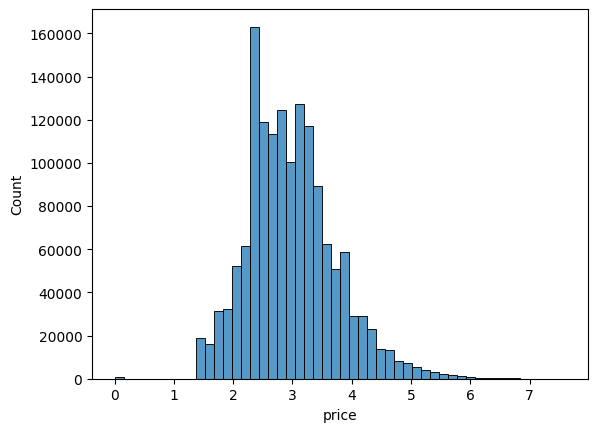

In [14]:
import numpy as np

y_train_df = np.log1p(y_train_df)
sns.histplot(y_train_df, bins=50)
plt.show()

-> 비교적 정규 분포에 가까운 데이터를 이룸
- 데이터 세트의 price 칼럼을 원래 값에서 로그로 변환된 값으로 변경

In [15]:
mercari_df['price']=np.log1p(mercari_df['price'])
mercari_df['price'].head(3)

,price
0,2.397895
1,3.970292
2,2.397895


- 다른 피처의 값 살피기 (shipping, item_condition_id)

In [16]:
print('Shipping 값 유형:\n', mercari_df['shipping'].value_counts())
print('item_condition_id 값 유형:\n', mercari_df['item_condition_id'].value_counts())

Shipping 값 유형:
 shipping
0    819435
1    663100
Name: count, dtype: int64
item_condition_id 값 유형:
 item_condition_id
1    640549
3    432161
2    375479
4     31962
5      2384
Name: count, dtype: int64


-> item_description 칼럼은 Null 값이 별로 없지만, description에 대한 별도 설명이 없는 경우 'No description yet'값으로 되어 있음
- 이러한 값이 얼마나 있는지 살펴봄

In [17]:
boolean_cond=mercari_df['item_description'].notnull()
mercari_df[boolean_cond]['item_description'].count()

np.int64(1482529)

-> 'No description yet'의 경우도 Null과 마찬가지로 의미있는 속성값으로는 사용될 수 없으므로 적절한 값으로 변경해야 함

- category_name

'/'로 분리된 카테고리를 하나의 문자열로 나타내고 있음

-> '/'를 기준으로 대, 중, 소분류를 효과적으로 분리해 내기 위해 별도의 split_cat() 함수 생성 후 이를 DataFrame의 apply lambda 식에 적용

- split_cat() 함수

-> category_name이 Null이 아닌 경우에 split('/')를 이용해 대, 중, 소분류를 분리

-> 문자열에 split(tokenizer문자) 함수를 호출하면 tokenizer 문자에 따라 문자열을 분리해 리스트로 반환함

-> category_name이 Null일 경우, split() 함수가 Error를 발생하므로 이 Error를 except catch하여 대, 중, 소 분류 모두 'Other Null'값을 부여

-> 대, 중, 소 칼럼은 mercari_df에서 cat_dae, cat_jung, cat_so로 부여

In [19]:
# apply lambda에서 호출되는 대, 중, 소 분할 함수 생셩, 대, 중, 소 값을 리스트로 반환
def split_cat(category_name):
    try:
        return category_name.split('/')

    except:
        return ['Other_Null', 'Other_Null', 'Other_Null']

# 위의 split_cat()을 apply lambda에서 호출해 대, 중, 소 칼럼을 mercari_df에 생성
mercari_df['cat_dae'], mercari_df['cat_jung'], mercari_df['cat_so'] = \
    zip(*mercari_df['category_name'].apply(lambda x : split_cat(x)))

# 대분류만 값의 유형과 건수를 살펴보고, 중분류, 소분류는 값의 유형이 많으므로 분류 개수만 추출
print('대분류 유형:\n', mercari_df['cat_dae'].value_counts())
print('중분류 유형:', mercari_df['cat_jung'].nunique())
print('소분류 유형:', mercari_df['cat_so'].nunique())

대분류 유형:
 cat_dae
Women                     664385
Beauty                    207828
Kids                      171689
Electronics               122690
Men                        93680
Home                       67871
Vintage & Collectibles     46530
Other                      45351
Handmade                   30842
Sports & Outdoors          25342
Other_Null                  6327
Name: count, dtype: int64
중분류 유형: 114
소분류 유형: 871


- brand_name, category_name, item_Description 칼럼의 Null 값은 일괄적으로 'Other Null'로 동일하게 변경

+) fillna()를 적용한 뒤에 각 칼럼별로 Null값이 없는지 다음과 같이 mercari_df.isnull( ).sum()을 호출해 확인하면 모든 칼럼에서 Null 건수가
0 임을 알 수 있음

In [20]:
mercari_df['brand_name'] = mercari_df['brand_name'].fillna(value='Other_Null')
mercari_df['category_name'] = mercari_df['category_name'].fillna(value='Other_Null')
mercari_df['item_description'] = mercari_df['item_description'].fillna(value='Other_Null')

# 각 컬럼별로 Null 값 건수 확인. 모두 0이 나와야 합니다.
mercari_df.isnull().sum()

,0
train_id,0
name,0
item_condition_id,0
category_name,0
brand_name,0
price,0
shipping,0
item_description,0
cat_dae,0
cat_jung,0


### **피처 인코딩과 피처 벡터화**
Mercari Price Suggestion에서 예측 모델은 price 값, 즉 상품 가격을 예측해야 하므로 회귀 모델을 기반으로 함
- 선형 회귀 모델과 회귀 트리 모델 모두 적용
- 특히 선형 회귀의 경우 원-핫 인코딩 적용이 훨씬 선호되므로 인코딩할 피처는 모두 원-핫 인코딩 적용
- 피처 벡터화) 비교적 짧은 텍스트는 Count 기반의 벡터화, 긴 텍스트는 TD-IDF 기반의 벡터화 적용

- brand_name

In [21]:
print('brand name의 유형 건수 :', mercari_df['brand_name'].nunique())
print('brand name sample 5건 : \n', mercari_df['brand_name'].value_counts()[:5])

brand name의 유형 건수 : 4810
brand name sample 5건 : 
 brand_name
Other_Null           632682
PINK                  54088
Nike                  54043
Victoria's Secret     48036
LuLaRoe               31024
Name: count, dtype: int64


-> brand_name - 원-핫 인코딩 변환

- name 속성

In [22]:
print('name의 종류 개수 :', mercari_df['name'].nunique())
print('name sample 7건: \n', mercari_df['name'][:7])

name의 종류 개수 : 1225273
name sample 7건: 
 0    MLB Cincinnati Reds T Shirt Size XL
1       Razer BlackWidow Chroma Keyboard
2                         AVA-VIV Blouse
3                  Leather Horse Statues
4                   24K GOLD plated rose
5       Bundled items requested for Ruie
6     Acacia pacific tides santorini top
Name: name, dtype: object


-> Count 기반으로 피처 벡터화 변환 적용

- category_name : cat_dae, cat_jung, cat_so 칼럼도 원-핫 인코딩 적용
- shipping : 0과 1, 두 가지 유형의 값. 원-핫 인코딩 적용
- item_condition_id : 상품 상태로서 1,2,3,4,5의 다섯 가지 유형의 값을 가짐. 원-핫 인코딩 적용

- item_description

In [23]:
pd.set_option('max_colwidth', 200)

# item_description의 평균 문자열 크기
print('item_description 평균 문자열 길이:', mercari_df['item_description'].str.len().mean())

mercari_df['item_description'][:2]

item_description 평균 문자열 길이: 145.71139703278507


,item_description
0,No description yet
1,This keyboard is in great condition and works like it came out of the box. All of the ports are tested and work perfectly. The lights are customizable via the Razer Synapse app on your PC.


-> TF-IDF로 변환

- 주요 칼럼을 인코딩 및 피처 벡터화 변환

    - name과 item_description 칼럼을 피처 벡터화
    - name 칼럼의 경우는 CountVbctorizer로, item_description 칼럼은 TfidfVectorizer로 변환
    - CountViectorizer는 기본 파라미터로, TfidfWctorizer는 max features = 50000으로 제한하고 n_gram은 triple gram인 ngram_range=(l,3), stop_words는 english로 설정

In [24]:
# name 속성에 대한 피처 벡터화 변환
cnt_vec = CountVectorizer()
X_name = cnt_vec.fit_transform(mercari_df.name)

# item_description에 대한 피처 벡터화 변환
tfidf_descp = TfidfVectorizer(max_features=50000, ngram_range=(1,3), stop_words='english')
X_descp = tfidf_descp.fit_transform(mercari_df['item_description'])

print('name vectorization shape:', X_name.shape)
print('item_description vectorization shape:', X_descp.shape)

name vectorization shape: (1482535, 105757)
item_description vectorization shape: (1482535, 50000)


- CountVectorizer, TfidfVectorizer가 fit_transform()을 통해 반환하는 데이터는 희소 행렬 형태이다
- 희소 행렬 객체 변수인 X_name과 X_descp를 새로 결합해 새로운 데이터 세트로 구성해야 함
- 앞으로 인코딩 될 cat dae, catjung, cat_so, brand_name, shipping, item_condition_id도 모두 X_name, X_descp와 결합돼 ML 모델을 실행하는 기반 데이터 세트로 재구성돼야 함

- 이를 위해 인코딩 대상 칼럼도 밀집 행렬 행태가 아닌 희소 행렬 형태로 인코딩을 적용한 뒤, 함께 결합
    - 사이킷런은 원-핫 인코딩을 위해 OneHotEncoder와 LabelBinarizer 클래스를 제공함. 이 중 LabelBinarizer 클래스는 희소 행렬 형태의 원-핫 인코딩 변환을 지원함.
    - 생성 시 sparse_out=True로 파라미터를 설정해주기만 하면 됨.
- 모든 인코딩 대상 칼럼은 LabelBinarizer를 이용해 희소 행렬 형태의 원-핫 인코딩으로 변환하겠다.
    - 개별 칼럼으로 만들어진 희소 행렬은 사이파이 패키지 sparse 모듈의 hstack( ) 함수를 이용해 결합
    - hstack( ) 함수는 희소 행렬을 손쉽게 칼럼 레벨로 결합할 수 있게 해줌.

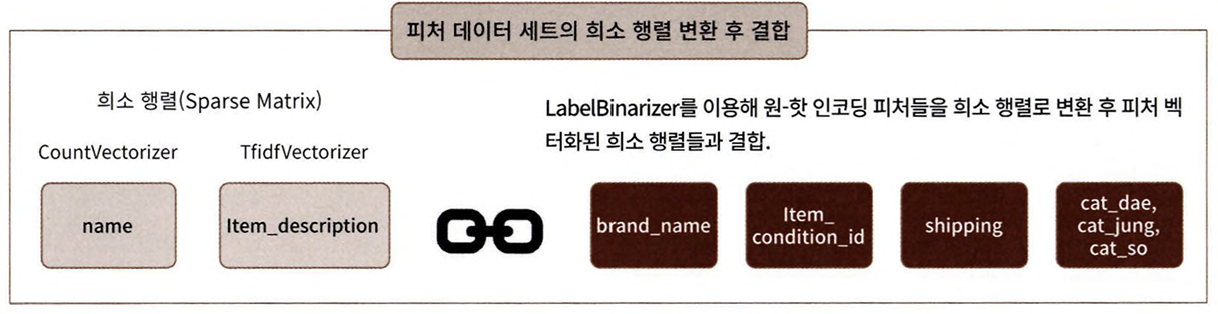

In [25]:
from sklearn.preprocessing import LabelBinarizer

# brand_name, item_condition_id, shipping 각 피처들을 희소 행렬 원-핫 인코딩 변환
lb_brand_name = LabelBinarizer(sparse_output=True)
X_brand = lb_brand_name.fit_transform(mercari_df['brand_name'])
lb_item_cond_id = LabelBinarizer(sparse_output=True)
X_item_cond_id = lb_item_cond_id.fit_transform(mercari_df['item_condition_id'])
lb_shipping = LabelBinarizer(sparse_output=True)
X_shipping = lb_shipping.fit_transform(mercari_df['shipping'])

# cat_dae, cat_jung, cat_so 각 피처들을 희소 행렬 원-핫 인코딩 변환
lb_cat_dae = LabelBinarizer(sparse_output=True)
X_cat_dae = lb_cat_dae.fit_transform(mercari_df['cat_dae'])
lb_cat_jung = LabelBinarizer(sparse_output=True)
X_cat_jung = lb_cat_jung.fit_transform(mercari_df['cat_jung'])
lb_cat_so = LabelBinarizer(sparse_output=True)
X_cat_so = lb_cat_so.fit_transform(mercari_df['cat_so'])

- 제대로 변환됐는지 생성된 인코딩 데이터 세트의 타입과 shape 살펴보기

In [26]:
print(type(X_brand), type(X_item_cond_id), type(X_shipping))
print('X_brand shape:{0}, X_item_cond_id shape:{1}'.format(X_brand.shape, X_item_cond_id.shape))
print('X_shipping shape:{0}, X_cat_dae shape:{1}'.format(X_shipping.shape, X_cat_dae.shape))
print('X_cat_jung shape:{0}, X_cat_so shape:{1}'.format(X_cat_jung.shape, X_cat_so.shape))

<class 'scipy.sparse._csr.csr_matrix'> <class 'scipy.sparse._csr.csr_matrix'> <class 'scipy.sparse._csr.csr_matrix'>
X_brand shape:(1482535, 4810), X_item_cond_id shape:(1482535, 5)
X_shipping shape:(1482535, 1), X_cat_dae shape:(1482535, 11)
X_cat_jung shape:(1482535, 114), X_cat_so shape:(1482535, 871)


-> 인코딩 변환된 데이터 세트가 CSR 형태로 변환된 csr_matrix 타입임

- 앞에서 피처 벡터화 변환한 데이터 세트와 희소 인코딩 변환된 데이터 세트를 hstack()을 이용해 모두 결합
    - 결합된 데이터는 Mercari Price Suggestion을 위한 기반 데이터 세트로 사용되는데, 여기서는 결합한 데이터의 타입과 크기만 확인하고 메모리에서 삭제할 것
    - 만들어진 결합 데이터가 비교적 많은 메모리를 잡아먹기 때문에 개인용 PC에서 메모리 오류가 발생할 수 있기에 del '객체 변수명' 과 gc.collect()로 결합 데이터를 메모리에서 삭제
    - 추후에 다양한 모델을 적용하므로 그때마다 다시 결합해 해당 데이터 세트를 이용하도록 하겠음

In [27]:
from scipy.sparse import hstack
import gc

sparse_matrix_list = (X_name, X_descp, X_brand, X_item_cond_id, \
                      X_shipping, X_cat_dae, X_cat_jung, X_cat_so)

# hstack 함수를 이용해 인코딩과 벡터화를 수행한 데이터 세트를 모두 결합.
X_features_sparse = hstack(sparse_matrix_list).tocsr()
print(type(X_features_sparse), X_features_sparse.shape)

# 데이터 세트가 메모리를 많이 차지하므로 사용 목적이 끝났으면 바로 메모리에서 삭제.
del X_features_sparse
gc.collect()

<class 'scipy.sparse._csr.csr_matrix'> (1482535, 161569)


118

-> hstack()으로 결합한 데이터 세트는 csr_matrix 타입이며, 총 161569개의 피처를 갖게 됨

-> 이제 만들어진 데이터 세트에 회귀를 적용해 price 값을 예측할 수 있도록 모델을 만들 차례!

### **릿지 회귀 모델 구축 및 평가**
먼저 모델을 평가하는 평가(Evalution)로직을 함수화
- 적용할 평가 지표 : RMSLE(Root Mean Square Logarithmic Error) -> RMSE와 유사하나 오류 값에 로그를 취해 RMSE를 구하는 방식

-> 낮은 가격(price)보다 높은 가격에서 오류가 발생할 경우 오류 값이 더 커지는 것을 억제하기 위해 이 방식을 도입함

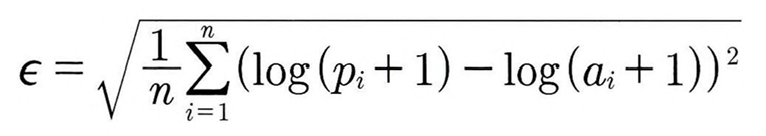

- 별도의 RMSLE를 구하는 함수를 rmsle((y, y_pred)로 생성
    - 원본 데이터의 price 칼럼의 값은 왜곡된 데이터 분포를 가지고 있기 때문에 이를 정규 분포 형태로 유도하기 위해 로그 값을 취해 변환
    - 즉, 학습할 모델이 사용할 price 값은 로그 값으로 변환된 price 값이므로 예측도 당연히 로그로 변환한 데이터 값 수준의 price 값을 예측할 것
    - 따라서 학습 모델을 이용한 예측된 price 값은 다시 로그의 역변환인 지수(Exponential) 변환을 수행해 원복해야 함

In [28]:
def rmsle(y,y_pred):
    # underflow, overflow를 막기 위해 log가 아닌 log1p로 rmsle 계산
    return np.sqrt(np.mean(np.power(np.log1p(y)-np.log1p(y_pred),2)))

def evaluate_org_price(y_test, preds):

    # 원본 데이터는 log1p로 변환되었으므로 exmpm1로 원복 필요
    preds_exmpm = np.expm1(preds)
    y_test_exmpm = np.expm1(y_test)

    # rmsle로 RMSLE 값 추출
    rmsle_result = rmsle(y_test_exmpm, preds_exmpm)
    return rmsle_result

- 학습용 데이터를 생성하고 모델을 학습/예측하는 로직을 별도의 함수로 만들기

-> 다음의 model_train_predict() 함수는 model 인자로 사이킷런의 회귀 estimator 객체를, matrix_list 인자로 최종 데이터 세트로 결합할 희소 행렬 리스트를 가짐

- 평가 데이터 세트는 train_test_split()을 이용해 전체 데이터의 20%로 하겠음

In [29]:
import gc
from scipy.sparse import hstack

def model_train_predict(model, matrix_list):
    # scipy.sparse 모듈의 hstack을 이용해 희소 행렬 결합
    X=hstack(matrix_list).tocsr()

    X_train, X_test, y_train, y_test=train_test_split(X, mercari_df['price'],
                                                      test_size=0.2, random_state=156)

    # 모델 학습 및 예측
    model.fit(X_train, y_train)
    preds = model.predict(X_test)

    del X_train, X_test, y_train
    gc.collect()

    return preds, y_test

- Ridge를 이용해 Mercari Price의 회귀 예측을 수행
    - 수행 전 Merari 상품 가격 예측에 item_description과 같은 텍스트 형태의 속성이 얼마나 영향을 미치는지 알아보자

In [30]:
linear_model = Ridge(solver = "lsqr", fit_intercept=False)

sparse_matrix_list = (X_name, X_brand, X_item_cond_id, \
                      X_shipping, X_cat_dae, X_cat_jung, X_cat_so)
linear_preds, y_test = model_train_predict(model=linear_model, matrix_list=sparse_matrix_list)
print('Item Description을 제외했을 때 rmsle 값:', evaluate_org_price(y_test, linear_preds))

sparse_matrix_list = (X_descp, X_name, X_brand, X_item_cond_id, \
                      X_shipping, X_cat_dae, X_cat_jung, X_cat_so)
linear_preds, y_test = model_train_predict(model=linear_model, matrix_list=sparse_matrix_list)
print('Item Description을 포함한 rmsle 값:', evaluate_org_price(y_test, linear_preds))

Item Description을 제외했을 때 rmsle 값: 0.4983990938999374
Item Description을 포함한 rmsle 값: 0.4680432471796771


Item Description을 포함했을 때 rmsle 값이 많이 감소함. Item description 영향이 중요함을 알 수 있음

### **LightGBM 회귀 모델 구축과 앙상블을 이용한 최종 예측 평가**
LightGBM을 이용해 회귀를 수행한 뒤, 위에서 구한 릿지 모델 예측값과 LightGBM 모델 예측값을 간단한 앙상블(Ensemble) 방식으로 섞어서 최종 회귀 예측값을 평가

- 먼저 LightGBM으로 회귀 수행

In [31]:
# from lightgbm import LGBMRegressor

# sparse_matrix_list = (X_descp, X_name, X_brand, X_item_cond_id,
#                      X_shipping, X_cat_dae, X_cat_jung, X_cat_so)

# lgbm_model = LGBMRegressor(n_estimators=200, learning_rate=0.5, num_leaves=125, random_state=156)
# lgbm_preds, y_test = model_train_predict(model=lgbm_model, matrix_list=sparse_matrix_list)
# print('LightGBM rmsle 값:', evaluate_org_price(y_test, lgbm_preds))

-  LightGBM의 예측 결괏값과 위에서 구한 Ridge의 예측 결괏값을 서로 앙상블해 최종 예측 결괏값을 도출

In [32]:
# preds = lgbm_preds * 0.45 + linear_preds * 0.55
# print('LightGBM과 Ridge를 ensemble한 최종 rmsle 값:', evaluate_org_price(y_test, preds))

-> 간단한 앙상블 방식으로 예측 성능을 더 개선함

### **정리**

- 텍스트 정규화 작업은 텍스트 클렌징 및 대소문자 변경, 단어 토큰화, 의미 없는 단어 필터링, 어근 추출 등 피처 벡터화를 진행하기 이전에 수행하는 다양한 사전 작업을 의미합니다. 피처 벡터화는 BOW의 대표 방식인 Count 기반과 TF-IDF 기반 피처 벡터화를 설명했습니다. 일반적으로 문서의 문장이 긴 경우 TF-IDF 기반의 피처 벡터가 더 정확한 결과를 도출하는 데 도움이 됩니다. 이렇게 만들어진 피처 벡터 데이터 세트는 희소 행렬이며, 머신러닝 모델은 이러한 희소 행렬 기반에서 최적화되어야 합니다.

- 텍스트 분류절에서는 문서들을 피처 벡터화한 후 로지스틱 회귀를 적용해 문서를 지도학습 방식으로 예측 분류해 봤습니다. 감성 분석절에서는 지도학습 기반으로 긍정/부정 이진 분류를 적용한 방식과 SentiWordNet, VADER와 같은 감성 사전 Lexicon을 이용한 방식 두 가지를 살펴봤습니다. 토픽 모델링은 LDA(Latent Dirichlet Allocation)를 이용해 뉴스그룹 내의 많은 문서들이 공통적으로 가지는 토픽들을 추출해 봤습니다. 텍스트 군집화는 K-평균 군집화 기법을 이용해 비슷한 문서들끼리 군집화했고 텍스트 유사도 측정에서는 코사인 유사도를 이용해 문서들끼리 얼마나 비슷한지를 측정해 봤습니다. 파이썬의 대표적인 한글 형태소 분석기인 KoNLPy 패키지를 이용해 네이버에서 제공하는 한글로 된 영화 리뷰에 긍정/부정 이진 분류를 적용해 봤습니다. 마지막으로 Mercari Price Challenge 실습에서는 정형 피처들과 텍스트와 같은 비정형 피처를 결합해 효과적으로 회귀 예측 모델을 구현했습니다.